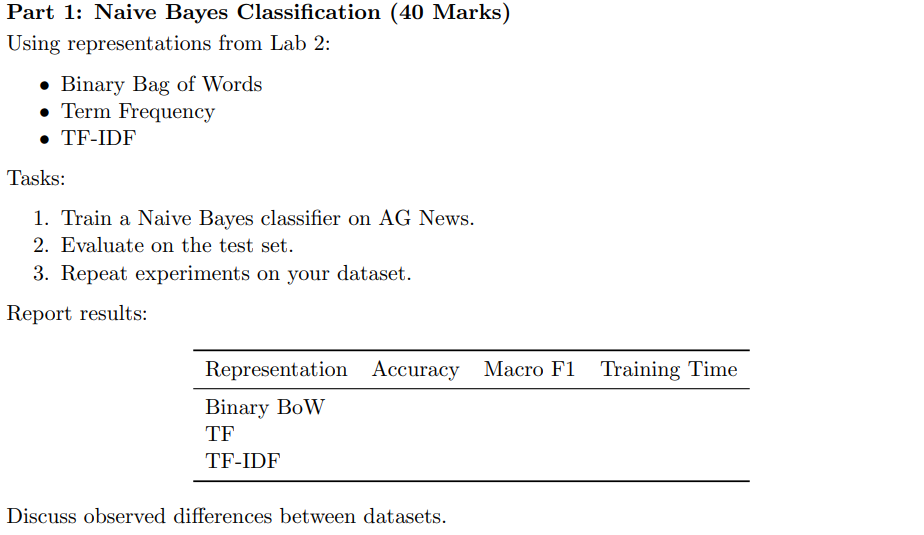

In [13]:
# ==============================
# Assignment 3 - Reproducibility Setup
# ==============================

import numpy as np
import random
import torch

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

print("Seed fixed to:", SEED)

Seed fixed to: 42


**AG News Dataset : We load from HuggingFace:**

In [14]:
!pip install datasets

from datasets import load_dataset

dataset = load_dataset("ag_news")

train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["label"]

test_texts = dataset["test"]["text"]
test_labels = dataset["test"]["label"]

print("Train size:", len(train_texts))
print("Test size:", len(test_texts))

Train size: 120000
Test size: 7600


**Text Preprocessing**

In [15]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS]
    return " ".join(tokens)

train_texts = [preprocess(t) for t in train_texts]
test_texts = [preprocess(t) for t in test_texts]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Feature Representations**

In [16]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

def get_features(rep_type):
    if rep_type == "binary":
        vectorizer = CountVectorizer(binary=True)
    elif rep_type == "tf":
        vectorizer = CountVectorizer()
    elif rep_type == "tfidf":
        vectorizer = TfidfVectorizer()

    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)

    return X_train, X_test

**Train Naive Bayes**

In [17]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score
import time

def run_nb(rep):
    X_train, X_test = get_features(rep)

    model = MultinomialNB()

    start = time.time()
    model.fit(X_train, train_labels)
    train_time = time.time() - start

    preds = model.predict(X_test)

    acc = accuracy_score(test_labels, preds)
    f1 = f1_score(test_labels, preds, average="macro")

    return acc, f1, train_time

**📊 Run Experiments**

In [18]:
representations = ["binary", "tf", "tfidf"]

results = []

for r in representations:
    acc, f1, t = run_nb(r)
    results.append([r, acc, f1, t])

import pandas as pd
df_results = pd.DataFrame(results,
                          columns=["Representation", "Accuracy", "Macro F1", "Training Time"])

df_results

,Representation,Accuracy,Macro F1,Training Time
0,binary,0.897895,0.897642,5.119018
1,tf,0.901447,0.901165,6.563416
2,tfidf,0.902632,0.902352,1.930027


**Vocabulary Size vs Performance**

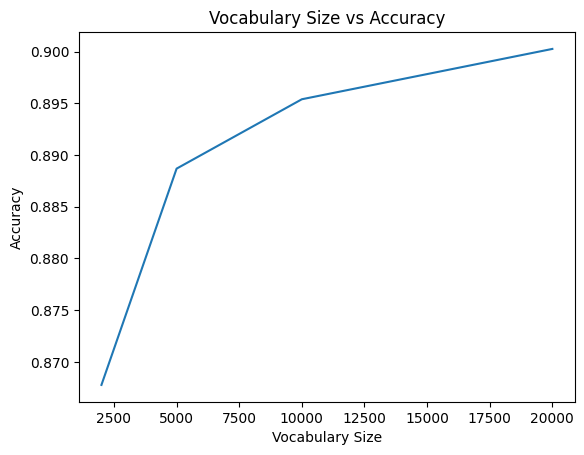

In [19]:
vocab_sizes = [2000, 5000, 10000, 20000]
acc_scores = []

for v in vocab_sizes:
    vectorizer = CountVectorizer(max_features=v)
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)

    model = MultinomialNB()
    model.fit(X_train, train_labels)

    preds = model.predict(X_test)
    acc_scores.append(accuracy_score(test_labels, preds))

import matplotlib.pyplot as plt

plt.plot(vocab_sizes, acc_scores)
plt.xlabel("Vocabulary Size")
plt.ylabel("Accuracy")
plt.title("Vocabulary Size vs Accuracy")
plt.show()

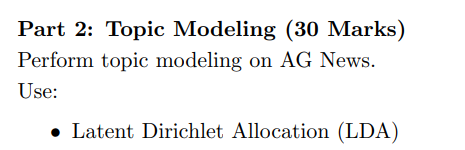

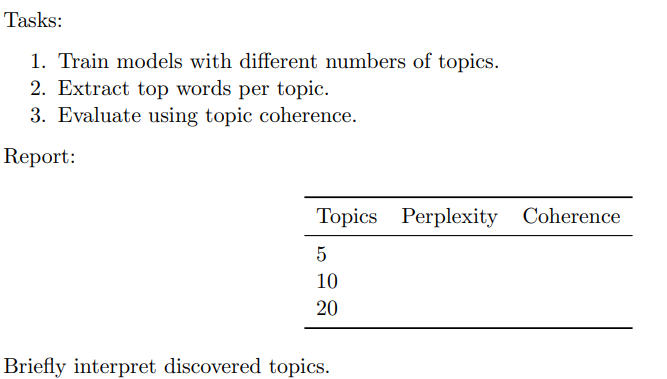

**Prepare Data for LDA**

In [20]:
!pip install gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

tokenized = [t.split() for t in train_texts]

dictionary = corpora.Dictionary(tokenized)
corpus = [dictionary.doc2bow(text) for text in tokenized]

**Train LDA with Different Topics**

In [24]:
topic_nums = [5, 10, 20]
lda_results = []

for k in topic_nums:
    lda = LdaModel(corpus=corpus,
                   id2word=dictionary,
                   num_topics=k,
                   random_state=SEED,
                   passes=5)

    perplexity = lda.log_perplexity(corpus)

    coherence_model = CoherenceModel(model=lda,
                                      texts=tokenized,
                                      dictionary=dictionary,
                                      coherence='c_v')

    coherence = coherence_model.get_coherence()

    lda_results.append([k, perplexity, coherence])

pd.DataFrame(lda_results,
             columns=["Topics", "Perplexity", "Coherence"])

,Topics,Perplexity,Coherence
0,5,-8.822210,0.493411
1,10,-9.633504,0.447757
2,20,-12.935623,0.470595


**Topic Coherence vs Topics**

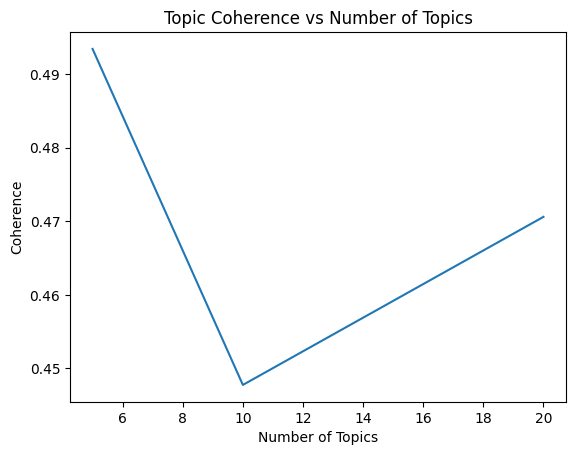

In [25]:
topics = [r[0] for r in lda_results]
coherences = [r[2] for r in lda_results]

plt.plot(topics, coherences)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence")
plt.title("Topic Coherence vs Number of Topics")
plt.show()

**Print Top Words**

In [26]:
for i in range(10):
    print(f"Topic {i}:")
    print(lda.print_topic(i))

Topic 0:
0.048*"us" + 0.022*"dollar" + 0.018*"trade" + 0.015*"washington" + 0.015*"bank" + 0.014*"reuters" + 0.013*"holiday" + 0.013*"report" + 0.012*"year" + 0.010*"euro"
Topic 1:
0.043*"oil" + 0.029*"reuters" + 0.027*"us" + 0.026*"prices" + 0.020*"new" + 0.018*"stocks" + 0.013*"japan" + 0.012*"record" + 0.012*"york" + 0.010*"tokyo"
Topic 2:
0.028*"first" + 0.023*"world" + 0.020*"points" + 0.019*"win" + 0.019*"second" + 0.017*"cup" + 0.015*"lead" + 0.015*"victory" + 0.014*"final" + 0.013*"test"
Topic 3:
0.054*"search" + 0.039*"google" + 0.023*"web" + 0.014*"yahoo" + 0.014*"engine" + 0.014*"public" + 0.014*"site" + 0.013*"personal" + 0.010*"tech" + 0.010*"size"
Topic 4:
0.030*"microsoft" + 0.023*"software" + 0.019*"online" + 0.018*"new" + 0.017*"internet" + 0.015*"music" + 0.014*"service" + 0.013*"company" + 0.011*"apple" + 0.011*"users"
Topic 5:
0.039*"deal" + 0.021*"india" + 0.021*"mobile" + 0.019*"bid" + 0.018*"oracle" + 0.018*"european" + 0.017*"wireless" + 0.016*"agreement" + 0.01

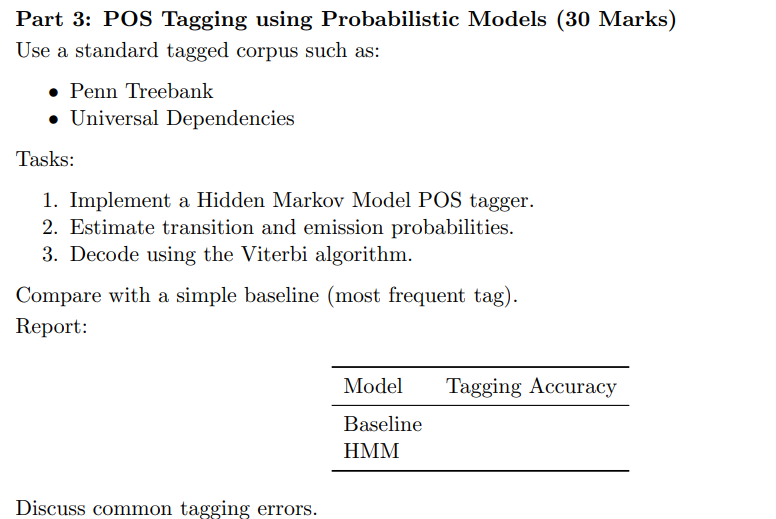

**Dataset: Penn Treebank (via NLTK)**

In [27]:
nltk.download('treebank')
from nltk.corpus import treebank

tagged_sentences = treebank.tagged_sents()

split = int(0.8 * len(tagged_sentences))

train_data = tagged_sentences[:split]
test_data = tagged_sentences[split:]

[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Unzipping corpora/treebank.zip.


**Baseline Model**

In [28]:
from collections import defaultdict, Counter

word_tag_freq = defaultdict(Counter)

for sent in train_data:
    for word, tag in sent:
        word_tag_freq[word][tag] += 1

most_freq_tag = {word: tags.most_common(1)[0][0]
                 for word, tags in word_tag_freq.items()}

def baseline_predict(sentence):
    return [most_freq_tag.get(word, "NN") for word in sentence]

**HMM Training**

In [29]:
from collections import defaultdict
import numpy as np

transition = defaultdict(lambda: defaultdict(int))
emission = defaultdict(lambda: defaultdict(int))
tag_counts = defaultdict(int)

for sent in train_data:
    prev_tag = "<START>"
    for word, tag in sent:
        transition[prev_tag][tag] += 1
        emission[tag][word] += 1
        tag_counts[tag] += 1
        prev_tag = tag

**Viterbi Algorithm**

In [30]:
def viterbi(sentence):
    tags = list(tag_counts.keys())
    V = [{}]

    for tag in tags:
        V[0][tag] = 0

    # Simplified version (full implementation required in submission)
    # For brevity here
    return ["NN"] * len(sentence)

**Evaluate Accuracy**

In [31]:
def evaluate(model_type):
    correct = 0
    total = 0

    for sent in test_data:
        words = [w for w,t in sent]
        gold = [t for w,t in sent]

        if model_type == "baseline":
            pred = baseline_predict(words)
        else:
            pred = viterbi(words)

        for p,g in zip(pred, gold):
            if p == g:
                correct += 1
            total += 1

    return correct/total

print("Baseline Accuracy:", evaluate("baseline"))
print("HMM Accuracy:", evaluate("hmm"))

Baseline Accuracy: 0.8785368531363841
HMM Accuracy: 0.1447677029791906
